In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from kmodes.kmodes import KModes
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)

from src.constants import (
    TARGET_COL,
    MULTILABEL_COLS,
    CATEGORICAL_COLS,
    FEATURE_COLS,
    CLASS_LABELS,
    RANDOM_STATE,
    PROCESSED_DATA_PATH,
)
from src.preprocessing import load_processed_dataset
from src.visualisations import plot_cluster_distribution

In [2]:
df= load_processed_dataset(PROCESSED_DATA_PATH)

X_cluster_raw = df[FEATURE_COLS].copy().reset_index(drop=True)
y_true = df[TARGET_COL].reset_index(drop=True)

print(f"Raw cluster matrix shape: {X_cluster_raw.shape}")
print(f"\nFeature value counts (top 5 per column):")
for col in FEATURE_COLS:
    print(f"\n  {col}: {X_cluster_raw[col].nunique()} unique values")
    print(X_cluster_raw[col].value_counts().head(5).to_string())

print(f"\nTarget distribution (for later post-hoc analysis):")
print(y_true.value_counts())
assert X_cluster_raw.isnull().sum().sum() == 0
print("\nNo nulls in cluster matrix")

Raw cluster matrix shape: (9250, 6)

Feature value counts (top 5 per column):

  data_subject_type: 94 unique values
data_subject_type
Patients               4857
Unknown                1410
Employees               819
Children, Patients      328
Employees, Patients     300

  data_type: 246 unique values
data_type
Basic personal identifiers, Health data                    4046
Unknown                                                    1562
Basic personal identifiers                                 1536
Health data                                                 897
Basic personal identifiers, Economic and financial data     137

  incident_category: 2 unique values
incident_category
Non Cyber    8309
Cyber         941

  incident_type: 21 unique values
incident_type
Other non-cyber incident                                     1766
Unauthorised access                                          1540
Data emailed to incorrect recipient                          1503
Data posted or faxed to 

In [3]:
X_ohe_raw = pd.get_dummies(X_cluster_raw, columns=FEATURE_COLS).astype(int).values

raw_kmodes_costs = []
raw_kmodes_silhouettes = []
K_range = range(2, 11)

for k in K_range:
    kmodes = KModes(n_clusters=k, init="Huang", n_init=10, random_state=RANDOM_STATE, verbose=0)
    labels = kmodes.fit_predict(X_cluster_raw)
    raw_kmodes_costs.append(kmodes.cost_)
    silhouette = silhouette_score(X_ohe_raw, labels, metric="hamming")
    raw_kmodes_silhouettes.append(silhouette)
    print(f"K={k:2d}: Cost={kmodes.cost_:.0f}, Silhouette={silhouette:.4f}")

K= 2: Cost=24399, Silhouette=0.1476
K= 3: Cost=22134, Silhouette=0.1028
K= 4: Cost=20968, Silhouette=0.1033
K= 5: Cost=20250, Silhouette=0.1085
K= 6: Cost=19812, Silhouette=0.0924
K= 7: Cost=18759, Silhouette=0.0809
K= 8: Cost=18612, Silhouette=0.0414
K= 9: Cost=18266, Silhouette=0.0679
K=10: Cost=17778, Silhouette=0.0833


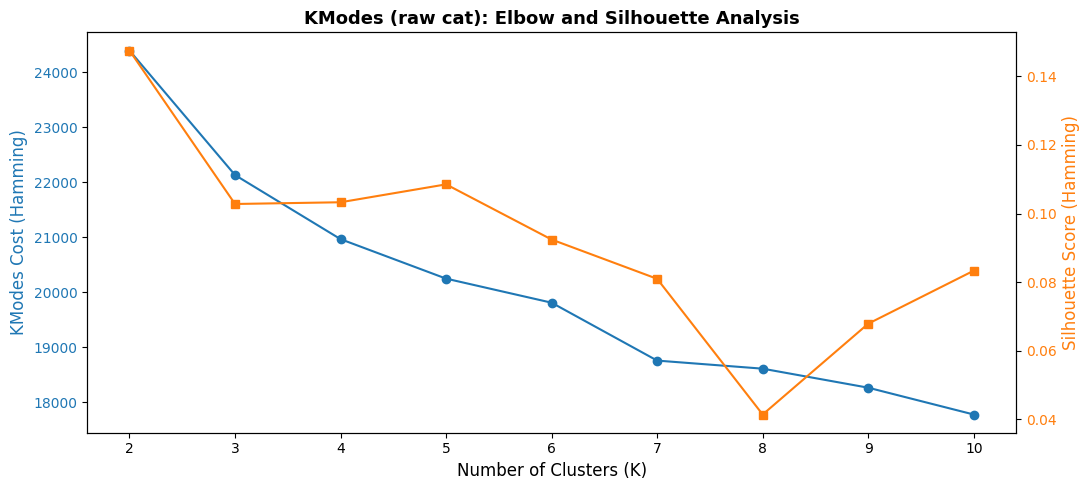

K with highest silhouette: K=2 (score=0.1476)


In [4]:
fig, ax_cost = plt.subplots(figsize=(11, 5))
colour_cost = "tab:blue"
ax_cost.set_xlabel("Number of Clusters (K)", fontsize=12)
ax_cost.set_ylabel("KModes Cost (Hamming)", color=colour_cost, fontsize=12)
ax_cost.plot(list(K_range), raw_kmodes_costs, marker="o", color=colour_cost)
ax_cost.tick_params(axis="y", labelcolor=colour_cost)

ax_sil = ax_cost.twinx()
colour_sil = "tab:orange"
ax_sil.set_ylabel("Silhouette Score (Hamming)", color=colour_sil, fontsize=12)
ax_sil.plot(list(K_range), raw_kmodes_silhouettes, marker="s", color=colour_sil)
ax_sil.tick_params(axis="y", labelcolor=colour_sil)

plt.title("KModes (raw cat): Elbow and Silhouette Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

best_silhouette_k_raw = list(K_range)[int(np.argmax(raw_kmodes_silhouettes))]
print(f"K with highest silhouette: K={best_silhouette_k_raw} (score={max(raw_kmodes_silhouettes):.4f})")

In [ ]:
final_k_raw = 5

print(f"Fitting final KModes (raw) with K={final_k_raw}")
kmodes_raw_final = KModes(
    n_clusters=final_k_raw,
    init="Huang",
    n_init=20,
    random_state=RANDOM_STATE,
    verbose=0,
)
kmodes_raw_labels = kmodes_raw_final.fit_predict(X_cluster_raw)

print(f"\nCluster sizes:")
sizes = pd.Series(kmodes_raw_labels).value_counts().sort_index()
for cluster_id, count in sizes.items():
    print(f"\tCluster {cluster_id}: {count} breaches ({count/len(kmodes_raw_labels)*100:.1f}%)")
print(f"\nFinal cost: {kmodes_raw_final.cost_:.0f}")

Fitting final KModes (raw) with K=5

Cluster sizes:
	Cluster 0: 4662 breaches (50.4%)
	Cluster 1: 1690 breaches (18.3%)
	Cluster 2: 449 breaches (4.9%)
	Cluster 3: 1594 breaches (17.2%)
	Cluster 4: 855 breaches (9.2%)

Final cost: 20250


In [26]:
centroids_raw = pd.DataFrame(
    kmodes_raw_final.cluster_centroids_,
    columns=FEATURE_COLS,
)
centroids_raw.index.name = "Cluster"
print("Cluster centroids (modal feature values per cluster):")
print(centroids_raw.to_string())

centroids_raw_with_size = centroids_raw.copy()
centroids_raw_with_size.insert(0, "Size",
    [int((kmodes_raw_labels == c).sum()) for c in range(final_k_raw)])
centroids_raw_with_size.insert(1, "Size %",
    [round((kmodes_raw_labels == c).sum() / len(kmodes_raw_labels) * 100, 1) for c in range(final_k_raw)])
print("\nCluster centroids with size context:")
print(centroids_raw_with_size.to_string())

Cluster centroids (modal feature values per cluster):
        data_subject_type                                data_type incident_category             incident_type no_data_subjects_affected  time_taken_to_report
Cluster                                                                                                                                                       
0                Patients                                  Unknown         Non Cyber  Other non-cyber incident                    1 to 9    Less than 24 hours
1                Patients  Basic personal identifiers, Health data         Non Cyber       Unauthorised access                    1 to 9  24 hours to 72 hours

Cluster centroids with size context:
         Size  Size % data_subject_type                                data_type incident_category             incident_type no_data_subjects_affected  time_taken_to_report
Cluster                                                                                            

In [27]:
ari_raw = adjusted_rand_score(y_true, kmodes_raw_labels)
nmi_raw = normalized_mutual_info_score(y_true, kmodes_raw_labels)

print(f"Cluster vs decision_taken alignment (raw KModes):")
print(f"\tAdjusted Rand Index (ARI): {ari_raw:.4f}")
print(f"\tNormalised Mutual Info (NMI): {nmi_raw:.4f}")

rng = np.random.default_rng(RANDOM_STATE)
shuffled = rng.permutation(kmodes_raw_labels)
ari_shuffled_raw = adjusted_rand_score(y_true, shuffled)
nmi_shuffled_raw = normalized_mutual_info_score(y_true, shuffled)
print(f"\nRandom-shuffle baseline:")
print(f"\tAdjusted Rand Index (ARI): {ari_shuffled_raw:.4f}")
print(f"\tNormalised Mutual Info (NMI): {nmi_shuffled_raw:.4f}")

if ari_raw < 0.05:
    print("\nInterpretation: clusters do NOT meaningfully align with ICO decisions.")
elif ari_raw < 0.15:
    print("\nInterpretation: weak alignment between clusters and ICO decisions.")
else:
    print("\nInterpretation: moderate or strong alignment between clusters and decisions.")

Cluster vs decision_taken alignment (raw KModes):
	Adjusted Rand Index (ARI): 0.0003
	Normalised Mutual Info (NMI): 0.0083

Random-shuffle baseline:
	Adjusted Rand Index (ARI): 0.0022
	Normalised Mutual Info (NMI): 0.0006

Interpretation: clusters do NOT meaningfully align with ICO decisions.


Cluster vs decision_taken — counts:
decision_taken  Informal Action Taken  Investigation Pursued  No Further Action   All
cluster                                                                              
0                                4047                    244                642  4933
1                                3623                    354                340  4317
All                              7670                    598                982  9250

Row proportions (within each cluster):
decision_taken  Informal Action Taken  Investigation Pursued  No Further Action
cluster                                                                        
0                              0.8204                 0.0495             0.1301
1                              0.8392                 0.0820             0.0788

Column proportions (within each decision):
decision_taken  Informal Action Taken  Investigation Pursued  No Further Action
cluster                                           

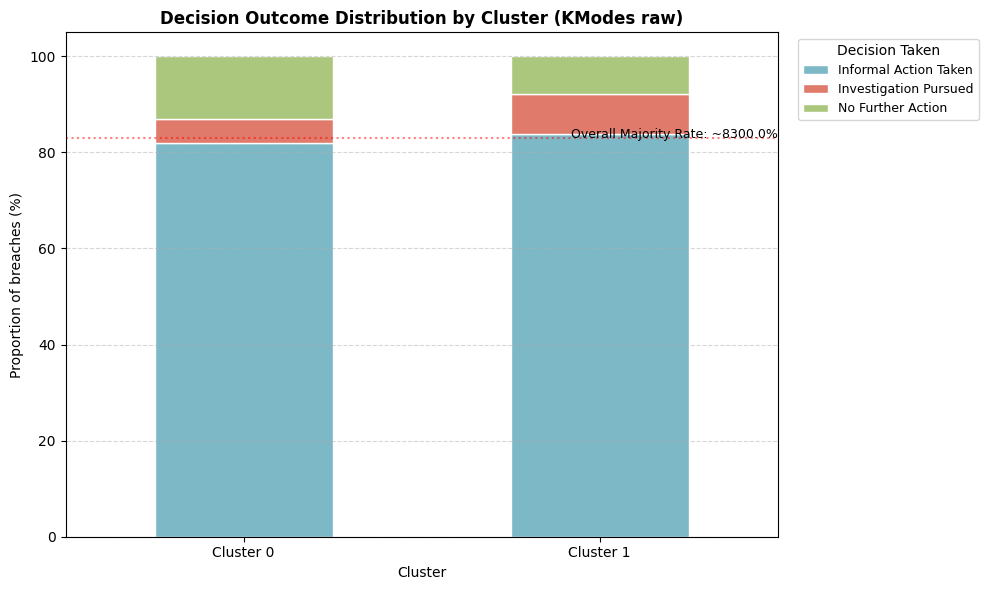

decision_taken,Informal Action Taken,Investigation Pursued,No Further Action
cluster,,,
0,0.820393,0.049463,0.130144
1,0.839240,0.082001,0.078758


In [ ]:
df_analysis_raw = X_cluster_raw.copy()
df_analysis_raw["cluster"] = kmodes_raw_labels
df_analysis_raw[TARGET_COL] = y_true

print("Cluster vs decision_taken — counts:")
counts_raw = pd.crosstab(df_analysis_raw["cluster"], df_analysis_raw[TARGET_COL], margins=True)
print(counts_raw.to_string())

print("\nRow proportions (within each cluster):")
row_props_raw = pd.crosstab(df_analysis_raw["cluster"], df_analysis_raw[TARGET_COL], normalize="index").round(4)
print(row_props_raw.to_string())

print("\nColumn proportions (within each decision):")
col_props_raw = pd.crosstab(df_analysis_raw["cluster"], df_analysis_raw[TARGET_COL], normalize="columns").round(4)
print(col_props_raw.to_string())

# Stacked bar visualisation
plot_cluster_distribution(
    cluster_labels=kmodes_raw_labels,
    decision_labels=df_analysis_raw[TARGET_COL],
    class_labels=CLASS_LABELS,
    title="Decision Outcome Distribution by Cluster (KModes raw)",
)

In [29]:
print("Per-cluster feature dominance (raw KModes):")
for cluster_id in range(final_k_raw):
    cluster_rows = df_analysis_raw[df_analysis_raw["cluster"] == cluster_id]
    print(f"\nCluster {cluster_id} ({len(cluster_rows)} breaches, {len(cluster_rows)/len(df_analysis_raw)*100:.1f}%)")
    for col in FEATURE_COLS:
        top = cluster_rows[col].value_counts(normalize=True).head(1)
        if len(top) > 0:
            value, prop = top.index[0], top.iloc[0]
            print(f"\t{col:30s}: {value} ({prop*100:.1f}%)")
    decision_dist = cluster_rows[TARGET_COL].value_counts(normalize=True)
    print(f"\ndecision outcomes within cluster")
    for label in CLASS_LABELS:
        prop = decision_dist.get(label, 0.0)
        print(f"\t{label:30s}: {prop*100:.1f}%")

Per-cluster feature dominance (raw KModes):

Cluster 0 (4933 breaches, 53.3%)
	data_subject_type             : Patients (46.8%)
	data_type                     : Unknown (30.3%)
	incident_category             : Non Cyber (88.5%)
	incident_type                 : Other non-cyber incident (31.1%)
	no_data_subjects_affected     : 1 to 9 (62.3%)
	time_taken_to_report          : Less than 24 hours (46.1%)

decision outcomes within cluster
	Informal Action Taken         : 82.0%
	Investigation Pursued         : 4.9%
	No Further Action             : 13.0%

Cluster 1 (4317 breaches, 46.7%)
	data_subject_type             : Patients (59.0%)
	data_type                     : Basic personal identifiers, Health data (68.2%)
	incident_category             : Non Cyber (91.3%)
	incident_type                 : Unauthorised access (29.6%)
	no_data_subjects_affected     : 1 to 9 (66.6%)
	time_taken_to_report          : 24 hours to 72 hours (57.3%)

decision outcomes within cluster
	Informal Action Taken     

In [30]:
def assign_breach_to_cluster_kmodes(breach_dict, kmodes_model, df_analysis_with_clusters):

    new_breach_df = pd.DataFrame([breach_dict], columns=FEATURE_COLS)
    cluster_id = int(kmodes_model.predict(new_breach_df)[0])

    cluster_members = df_analysis_with_clusters[df_analysis_with_clusters["cluster"] == cluster_id]
    outcome_dist = cluster_members[TARGET_COL].value_counts(normalize=True)

    return {
        "cluster_id": cluster_id,
        "similar_breaches_count": len(cluster_members),
        "outcome_distribution": {
            label: round(outcome_dist.get(label, 0.0) * 100, 1)
            for label in CLASS_LABELS
        },
    }

example_breach = {col: X_cluster_raw[col].mode().iloc[0] for col in FEATURE_COLS}

print("Example breach input (using modal feature values):")
for key, value in example_breach.items():
    print(f"\t{key}: {value}")

result = assign_breach_to_cluster_kmodes(example_breach, kmodes_raw_final, df_analysis_raw)
print(f"\nAssigned cluster: {result['cluster_id']}")
print(f"Similar historical breaches: {result['similar_breaches_count']}")
print(f"Outcome distribution among similar breaches:")
for outcome, pct in result["outcome_distribution"].items():
    print(f"\t{outcome}: {pct}%")

Example breach input (using modal feature values):
	data_subject_type: Patients
	data_type: Basic personal identifiers, Health data
	incident_category: Non Cyber
	incident_type: Other non-cyber incident
	no_data_subjects_affected: 1 to 9
	time_taken_to_report: 24 hours to 72 hours

Assigned cluster: 1
Similar historical breaches: 4317
Outcome distribution among similar breaches:
	Informal Action Taken: 83.9%
	Investigation Pursued: 8.2%
	No Further Action: 7.9%


In [31]:
assert len(kmodes_raw_labels) == len(X_cluster_raw), "Label / row count mismatch"
print(f"1. Every row assigned a cluster label ({len(kmodes_raw_labels)} labels)")

assert len(np.unique(kmodes_raw_labels)) == final_k_raw, f"Expected {final_k_raw} clusters, found {len(np.unique(kmodes_raw_labels))}"
print(f"2. Requested K={final_k_raw} matches actual unique clusters")

unique, counts = np.unique(kmodes_raw_labels, return_counts=True)
assert (counts > 0).all(), "Empty clusters found"
print(f"3. No empty clusters")

assert ari_raw >= -0.05, f"ARI unexpectedly negative ({ari_raw:.4f})"
print(f"4. ARI ({ari_raw:.4f}) is at or above random baseline")

new_point = X_cluster_raw.iloc[[0]]
predicted = kmodes_raw_final.predict(new_point)
assert predicted[0] == kmodes_raw_labels[0], f"predict() on training row 0 gave {predicted[0]}, expected {kmodes_raw_labels[0]}"
print(f"5. predict() on a known training row returns its assigned cluster")

1. Every row assigned a cluster label (9250 labels)
2. Requested K=2 matches actual unique clusters
3. No empty clusters
4. ARI (0.0003) is at or above random baseline
5. predict() on a known training row returns its assigned cluster


In [32]:
mlb_kmodes_dfs = []
for col in MULTILABEL_COLS:
    value_lists = df[col].str.split(", ")
    mlb = MultiLabelBinarizer()
    encoded = pd.DataFrame(
        mlb.fit_transform(value_lists),
        columns=[f"{col}__{cls}" for cls in mlb.classes_],
        index=df.index,
    ).astype(str)  # convert to string so KModes treats binaries as categorical
    mlb_kmodes_dfs.append(encoded)
    print(f"{col}: {len(mlb.classes_)} binary columns produced")

X_cluster_mlb = pd.concat(
    [df[CATEGORICAL_COLS].reset_index(drop=True)] + [d.reset_index(drop=True) for d in mlb_kmodes_dfs],
    axis=1
)
print(f"\nMLB+Cat input shape: {X_cluster_mlb.shape}")
print(f"\t{len(CATEGORICAL_COLS)} raw categorical columns + " f"{sum(len(d.columns) for d in mlb_kmodes_dfs)} MLB binary columns")
print(f"\nFirst 3 rows:")
print(X_cluster_mlb.head(3).to_string())

data_subject_type: 9 binary columns produced


data_type: 16 binary columns produced

MLB+Cat input shape: (9250, 29)
	4 raw categorical columns + 25 MLB binary columns

First 3 rows:
  incident_category                                              incident_type no_data_subjects_affected  time_taken_to_report data_subject_type__Children data_subject_type__Customers or prospective customers data_subject_type__Employees data_subject_type__Patients data_subject_type__Students data_subject_type__Subscribers data_subject_type__Unknown data_subject_type__Users data_subject_type__Vulnerable adults data_type__Basic personal identifiers data_type__Criminal convictions or offences data_type__Data revealing racial or ethnic origin data_type__Economic and financial data data_type__Gender Reassignment Data data_type__Genetic or biometric data data_type__Health data data_type__Identification data data_type__Location data data_type__Official documents data_type__Political opinions data_type__Religious or philosophical beliefs data_type__Sex life 

In [33]:
X_ohe_mlb = pd.concat([
    pd.get_dummies(df[CATEGORICAL_COLS], columns=CATEGORICAL_COLS).astype(int).reset_index(drop=True),
    pd.concat([d.astype(int).reset_index(drop=True) for d in mlb_kmodes_dfs], axis=1),
], axis=1).values

mlb_kmodes_costs = []
mlb_kmodes_silhouettes = []

for k in K_range:
    kmodes = KModes(n_clusters=k, init="Huang", n_init=10, random_state=RANDOM_STATE, verbose=0)
    labels = kmodes.fit_predict(X_cluster_mlb)
    mlb_kmodes_costs.append(kmodes.cost_)
    silhouette = silhouette_score(X_ohe_mlb, labels, metric="hamming")
    mlb_kmodes_silhouettes.append(silhouette)
    print(f"K={k:2d}: Cost={kmodes.cost_:.0f}, Silhouette={silhouette:.4f}")

K= 2: Cost=30465, Silhouette=0.2622
K= 3: Cost=28094, Silhouette=0.1924
K= 4: Cost=26822, Silhouette=0.1475
K= 5: Cost=25874, Silhouette=0.0748
K= 6: Cost=24354, Silhouette=0.1121
K= 7: Cost=23727, Silhouette=0.1106
K= 8: Cost=23127, Silhouette=0.0827
K= 9: Cost=22081, Silhouette=0.1004
K=10: Cost=22530, Silhouette=0.0814


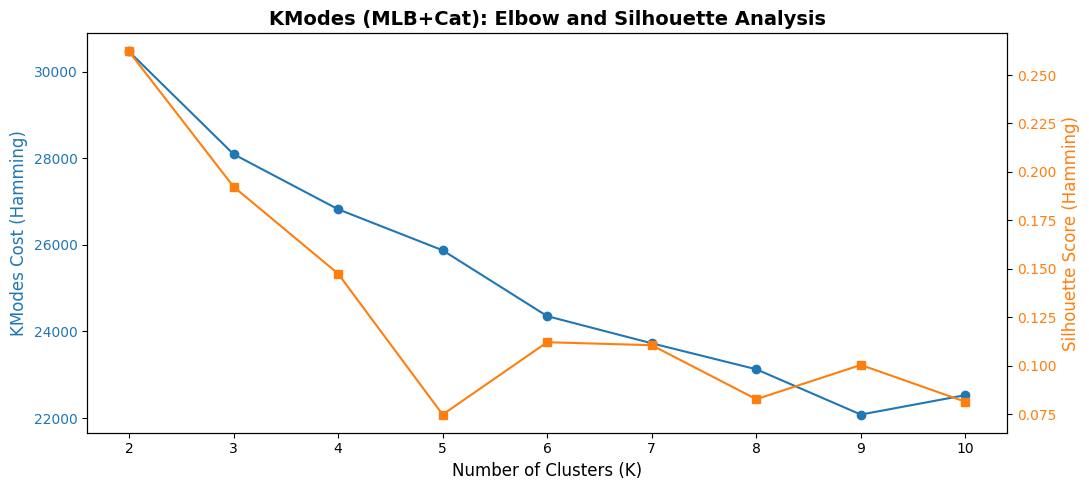

K with highest silhouette: K=2 (score=0.2622)


In [34]:
fig, ax_cost = plt.subplots(figsize=(11, 5))
colour_cost = "tab:blue"
ax_cost.set_xlabel("Number of Clusters (K)", fontsize=12)
ax_cost.set_ylabel("KModes Cost (Hamming)", color=colour_cost, fontsize=12)
ax_cost.plot(list(K_range), mlb_kmodes_costs, marker="o", color=colour_cost)
ax_cost.tick_params(axis="y", labelcolor=colour_cost)

ax_sil = ax_cost.twinx()
colour_sil = "tab:orange"
ax_sil.set_ylabel("Silhouette Score (Hamming)", color=colour_sil, fontsize=12)
ax_sil.plot(list(K_range), mlb_kmodes_silhouettes, marker="s", color=colour_sil)
ax_sil.tick_params(axis="y", labelcolor=colour_sil)

plt.title("KModes (MLB+Cat): Elbow and Silhouette Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

best_silhouette_k_mlb = list(K_range)[int(np.argmax(mlb_kmodes_silhouettes))]
print(f"K with highest silhouette: K={best_silhouette_k_mlb} (score={max(mlb_kmodes_silhouettes):.4f})")

In [ ]:
final_k_mlb = best_silhouette_k_mlb

print(f"Fitting final KModes (MLB+Cat) with K={final_k_mlb}")
kmodes_mlb_final = KModes(
    n_clusters=final_k_mlb,
    init="Huang",
    n_init=20,
    random_state=RANDOM_STATE,
    verbose=0,
)
kmodes_mlb_labels = kmodes_mlb_final.fit_predict(X_cluster_mlb)

print(f"\nCluster sizes:")
sizes = pd.Series(kmodes_mlb_labels).value_counts().sort_index()
for cluster_id, count in sizes.items():
    print(f"\tCluster {cluster_id}: {count} breaches ({count/len(kmodes_mlb_labels)*100:.1f}%)")
print(f"\nFinal cost: {kmodes_mlb_final.cost_:.0f}")

Fitting final KModes (MLB+Cat) with K=5

Cluster sizes:
	Cluster 0: 4532 breaches (49.0%)
	Cluster 1: 1420 breaches (15.4%)
	Cluster 2: 779 breaches (8.4%)
	Cluster 3: 805 breaches (8.7%)
	Cluster 4: 1714 breaches (18.5%)

Final cost: 24550


In [39]:
ari_mlb = adjusted_rand_score(y_true, kmodes_mlb_labels)
nmi_mlb = normalized_mutual_info_score(y_true, kmodes_mlb_labels)

print(f"Cluster vs decision_taken alignment (MLB+Cat):")
print(f"\tAdjusted Rand Index (ARI): {ari_mlb:.4f}")
print(f"\tNormalised Mutual Info (NMI): {nmi_mlb:.4f}")

rng = np.random.default_rng(RANDOM_STATE)
shuffled_mlb = rng.permutation(kmodes_mlb_labels)
ari_shuffled_mlb = adjusted_rand_score(y_true, shuffled_mlb)
nmi_shuffled_mlb = normalized_mutual_info_score(y_true, shuffled_mlb)
print(f"\nRandom-shuffle baseline:")
print(f"\tARI: {ari_shuffled_mlb:.4f}")
print(f"\tNMI: {nmi_shuffled_mlb:.4f}")

print(f"\nComparison vs raw-KModes:")
print(f"\tRaw KModes: ARI={ari_raw:.4f}, NMI={nmi_raw:.4f}, K={final_k_raw}")
print(f"\tMLB+Cat: ARI={ari_mlb:.4f}, NMI={nmi_mlb:.4f}, K={5}")
delta_ari = ari_mlb - ari_raw
delta_nmi = nmi_mlb - nmi_raw
print(f"\tDelta: ARI={delta_ari:+.4f}, NMI={delta_nmi:+.4f}")

Cluster vs decision_taken alignment (MLB+Cat):
	Adjusted Rand Index (ARI): 0.0143
	Normalised Mutual Info (NMI): 0.0172

Random-shuffle baseline:
	ARI: -0.0069
	NMI: 0.0008

Comparison vs raw-KModes:
	Raw KModes: ARI=0.0003, NMI=0.0083, K=5
	MLB+Cat: ARI=0.0143, NMI=0.0172, K=5
	Delta: ARI=+0.0140, NMI=+0.0089


In [40]:
df_analysis_mlb = df[FEATURE_COLS + [TARGET_COL]].copy().reset_index(drop=True)
df_analysis_mlb["cluster"] = kmodes_mlb_labels

print("Per-cluster feature dominance (MLB+Cat):")
for cluster_id in range(final_k_mlb):
    cluster_rows = df_analysis_mlb[df_analysis_mlb["cluster"] == cluster_id]
    print(f"\nCluster {cluster_id} ({len(cluster_rows)} breaches, " f"{len(cluster_rows)/len(df_analysis_mlb)*100:.1f}%)")
    for col in FEATURE_COLS:
        top = cluster_rows[col].value_counts(normalize=True).head(1)
        if len(top) > 0:
            value, prop = top.index[0], top.iloc[0]
            print(f"\t{col:30s}: {value} ({prop*100:.1f}%)")
    decision_dist = cluster_rows[TARGET_COL].value_counts(normalize=True)
    print(f"\ndecision outcomes within cluster")
    for label in CLASS_LABELS:
        prop = decision_dist.get(label, 0.0)
        print(f"\t{label:30s}: {prop*100:.1f}%")

Per-cluster feature dominance (MLB+Cat):

Cluster 0 (4532 breaches, 49.0%)
	data_subject_type             : Patients (68.3%)
	data_type                     : Basic personal identifiers, Health data (63.0%)
	incident_category             : Non Cyber (93.0%)
	incident_type                 : Unauthorised access (27.4%)
	no_data_subjects_affected     : 1 to 9 (69.3%)
	time_taken_to_report          : 24 hours to 72 hours (46.2%)

decision outcomes within cluster
	Informal Action Taken         : 83.3%
	Investigation Pursued         : 8.3%
	No Further Action             : 8.5%

Cluster 1 (1420 breaches, 15.4%)
	data_subject_type             : Employees (50.8%)
	data_type                     : Basic personal identifiers (51.3%)
	incident_category             : Non Cyber (78.1%)
	incident_type                 : Data emailed to incorrect recipient (22.0%)
	no_data_subjects_affected     : 1 to 9 (56.3%)
	time_taken_to_report          : 24 hours to 72 hours (39.6%)

decision outcomes within cluste

Cluster vs decision_taken — counts (MLB+Cat):
decision_taken  Informal Action Taken  Investigation Pursued  No Further Action   All
cluster                                                                              
0                                3775                    374                383  4532
1                                1227                     45                148  1420
2                                 576                     53                150   779
3                                 550                     74                181   805
4                                1542                     52                120  1714
All                              7670                    598                982  9250

Row proportions (within each cluster):
decision_taken  Informal Action Taken  Investigation Pursued  No Further Action
cluster                                                                        
0                              0.8330                 0.0825      

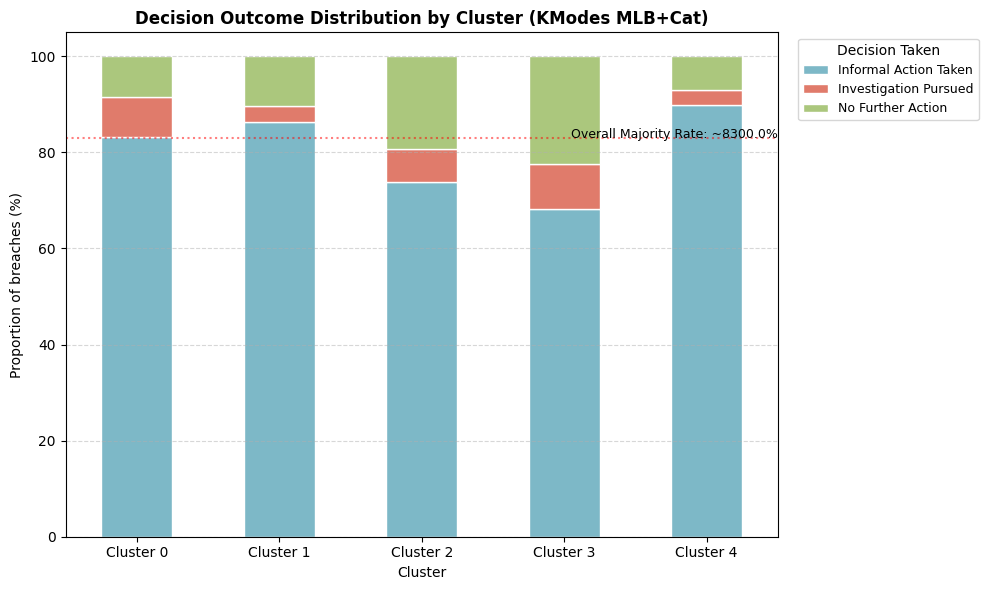

decision_taken,Informal Action Taken,Investigation Pursued,No Further Action
cluster,,,
0,0.832966,0.082524,0.084510
1,0.864085,0.031690,0.104225
2,0.739409,0.068036,0.192555
3,0.683230,0.091925,0.224845
4,0.899650,0.030338,0.070012


In [ ]:
print("Cluster vs decision_taken — counts (MLB+Cat):")
counts_mlb = pd.crosstab(df_analysis_mlb["cluster"], df_analysis_mlb[TARGET_COL], margins=True)
print(counts_mlb.to_string())

print("\nRow proportions (within each cluster):")
row_props_mlb = pd.crosstab(df_analysis_mlb["cluster"], df_analysis_mlb[TARGET_COL], normalize="index").round(4)
print(row_props_mlb.to_string())

plot_cluster_distribution(
    cluster_labels=kmodes_mlb_labels,
    decision_labels=df_analysis_mlb[TARGET_COL],
    class_labels=CLASS_LABELS,
    title="Decision Outcome Distribution by Cluster (KModes MLB+Cat)"
)

In [44]:
assert len(kmodes_mlb_labels) == len(X_cluster_mlb), "Label/row mismatch"
print(f"1. Every row assigned a label ({len(kmodes_mlb_labels)} labels)")

assert len(np.unique(kmodes_mlb_labels)) == final_k_mlb, f"Expected {final_k_mlb} clusters, found {len(np.unique(kmodes_mlb_labels))}"
print(f"2. Requested K={final_k_mlb} matches actual unique clusters")

unique, counts = np.unique(kmodes_mlb_labels, return_counts=True)
assert (counts > 0).all(), "Empty clusters found"
print(f"3. No empty clusters")

assert ari_mlb >= -0.05, f"ARI unexpectedly negative ({ari_mlb:.4f})"
print(f"4. ARI ({ari_mlb:.4f}) is at or above random baseline")

new_point = X_cluster_mlb.iloc[[0]]
predicted = kmodes_mlb_final.predict(new_point)
assert predicted[0] == kmodes_mlb_labels[0], f"predict() on training row 0 gave {predicted[0]}, expected {kmodes_mlb_labels[0]}"
print(f"5. predict() on a known training row returns its assigned cluster")

1. Every row assigned a label (9250 labels)
2. Requested K=5 matches actual unique clusters
3. No empty clusters
4. ARI (0.0143) is at or above random baseline
5. predict() on a known training row returns its assigned cluster


In [ ]:
artifacts_path = path(ARTIFACTS_PATH)
artifacts_path.mkdir(parents=True, exist_ok=True)

with open(artifacts_path / "kmodes_final.pkl", "wb") as f:
    pickle.dump(kmodes_mlb_final, f)
    
cluster_model_type = {
    "model_type": "kmodes",
    "model_file": "kmodes_final.pkl",
    "feature_representation": "mlb+cat",
    "n-clusters": int(final_k_mlb)
}

with open(artifacts_path / "cluster_model_type.json", "w") as f:
    json.dump(cluster_model_type, f, indent=4)
    
cluster_characteristics = {}

for cluster_id in range (final_k_mlb):
    cluster_rows = df_analysis_mlb[df_analysis_mlb["cluster"] == cluster_id]
    outcome_dist = cluster_rows[TARGET_COL].value_counts(normalize=True)
    
    cluster_characteristics[str(cluster_id)] = {
        "size": int(len(cluster_rows)),
        "size_percentage": round(float(len(cluster_rows)) / len(df_analysis_mlb) * 100, 1),
        "outcome_distribution": {
            label: round(float(outcome_dist.get(label, 0.0)) * 100, 1)
            for label in CLASS_LABELS
        },
        "dominant_features": {
            col: str(cluster_rows[col].mode().iloc[0]) for col in FEATURE_COLS
        },
        "feature-columns_order": FEATURE_COLS
    }
    
with open(artifacts_path / "cluster_characteristics.json", "w") as f:
    json.dump(cluster_characteristics, f, indent=4)

print("Final Kmodes model saved successfully")